# PROYECTO FINAL    
## Fase 1: Exploración y análisis de los datos (EDA)    
En esta primera parte anañizamos el dataset completo para entender la estructura de los datos, entender mejor que variables tenemos y que tipo de información aportan. Vamos a detectar valores nulos, duplicados y clases desbalanceadas, y preparar las variables para los modelos de clasificación y regresión.

## 1. Importaciones

In [328]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

sys.path.append(os.path.abspath('..'))
from src.preprocesado import plot_bar_frecuencias, plot_hist_box

## 2. Carga y visión general de los datos   

In [329]:
ruta = "C:/Users/veror/MACHINE_LEARN/PROYECTO/Aprendizaje_automatico_proyecto_final/data/rendimiento_estudiantes.csv"
dataset = pd.read_csv(ruta, sep=";")
df = dataset.copy()

print("Dimensiones: ", df.shape)
df.head()

Dimensiones:  (4424, 37)


,estado_civil,modo_solicitud,orden_solicitud,curso,asistencia_diurna_vespertina,cualificacion_previa,nota_cualificacion_previa,nacionalidad,cualificacion_madre,cualificacion_padre,...,asignaturas_2sem_convalidadas,asignaturas_2sem_matriculadas,asignaturas_2sem_evaluadas,asignaturas_2sem_aprobadas,nota_media_2sem,asignaturas_2sem_sin_evaluacion,tasa_desempleo,tasa_inflacion,pib,objetivo
0,soltero/a,2a_fase_contingente_general,5,animacion_y_diseno_multimedia,diurna,educacion_secundaria,122.0,portuguesa,educacion_basica_3er_ciclo_o_equivalente,otro_11o_ano,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,abandono
1,soltero/a,estudiante_internacional_licenciatura,1,turismo,diurna,educacion_secundaria,160.0,portuguesa,educacion_secundaria_12o_ano_o_equivalente,educacion_superior_grado,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,graduado
2,soltero/a,1a_fase_contingente_general,5,diseno_de_comunicacion,diurna,educacion_secundaria,122.0,portuguesa,educacion_basica_1er_ciclo_o_equivalente,educacion_basica_1er_ciclo_o_equivalente,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,abandono
3,soltero/a,2a_fase_contingente_general,2,periodismo_y_comunicacion,diurna,educacion_secundaria,122.0,portuguesa,educacion_basica_2o_ciclo_o_equivalente,educacion_basica_1er_ciclo_o_equivalente,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,graduado
4,casado/a,mayor_de_23_anos,1,servicio_social_nocturno,vespertina,educacion_secundaria,100.0,portuguesa,educacion_basica_1er_ciclo_o_equivalente,educacion_basica_2o_ciclo_o_equivalente,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,graduado


In [330]:
# Eliminamos duplicados 
print("Filas originales: ", len(df))
df = df.drop_duplicates()
print("FIlas después de borrar duplicados: ", len(df))

Filas originales:  4424
FIlas después de borrar duplicados:  4424


In [331]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   estado_civil                       4424 non-null   object 
 1   modo_solicitud                     4424 non-null   object 
 2   orden_solicitud                    4424 non-null   int64  
 3   curso                              4424 non-null   object 
 4   asistencia_diurna_vespertina       4424 non-null   object 
 5   cualificacion_previa               4424 non-null   object 
 6   nota_cualificacion_previa          4424 non-null   float64
 7   nacionalidad                       4424 non-null   object 
 8   cualificacion_madre                4424 non-null   object 
 9   cualificacion_padre                4424 non-null   object 
 10  ocupacion_madre                    4424 non-null   object 
 11  ocupacion_padre                    4424 non-null   objec

In [332]:
df.describe()

,orden_solicitud,nota_cualificacion_previa,nota_admision,edad_al_matricularse,asignaturas_1sem_convalidadas,asignaturas_1sem_matriculadas,asignaturas_1sem_evaluadas,asignaturas_1sem_aprobadas,nota_media_1sem,asignaturas_1sem_sin_evaluacion,asignaturas_2sem_convalidadas,asignaturas_2sem_matriculadas,asignaturas_2sem_evaluadas,asignaturas_2sem_aprobadas,nota_media_2sem,asignaturas_2sem_sin_evaluacion,tasa_desempleo,tasa_inflacion,pib
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.727848,132.613314,126.978119,23.265145,0.709991,6.270570,8.299051,4.706600,10.640822,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,1.313793,13.188332,14.482001,7.587816,2.360507,2.480178,4.179106,3.094238,4.843663,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,0.000000,95.000000,95.000000,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,125.000000,117.900000,19.000000,0.000000,5.000000,6.000000,3.000000,11.000000,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,133.100000,126.100000,20.000000,0.000000,6.000000,8.000000,5.000000,12.285714,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,2.000000,140.000000,134.800000,25.000000,0.000000,7.000000,10.000000,6.000000,13.400000,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,9.000000,190.000000,190.000000,70.000000,20.000000,26.000000,45.000000,26.000000,18.875000,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


In [333]:
df.columns

Index(['estado_civil', 'modo_solicitud', 'orden_solicitud', 'curso',
       'asistencia_diurna_vespertina', 'cualificacion_previa',
       'nota_cualificacion_previa', 'nacionalidad', 'cualificacion_madre',
       'cualificacion_padre', 'ocupacion_madre', 'ocupacion_padre',
       'nota_admision', 'desplazado', 'necesidades_educativas_especiales',
       'deudor', 'matricula_al_dia', 'genero', 'becado',
       'edad_al_matricularse', 'internacional',
       'asignaturas_1sem_convalidadas', 'asignaturas_1sem_matriculadas',
       'asignaturas_1sem_evaluadas', 'asignaturas_1sem_aprobadas',
       'nota_media_1sem', 'asignaturas_1sem_sin_evaluacion',
       'asignaturas_2sem_convalidadas', 'asignaturas_2sem_matriculadas',
       'asignaturas_2sem_evaluadas', 'asignaturas_2sem_aprobadas',
       'nota_media_2sem', 'asignaturas_2sem_sin_evaluacion', 'tasa_desempleo',
       'tasa_inflacion', 'pib', 'objetivo'],
      dtype='object')

In [334]:
# Comprobamos si hay valores faltantes
faltantes = df.isna().sum()
print("Número total de valores faltantes:", faltantes.sum())

Número total de valores faltantes: 0


## 3. Variable objetivo
La vairbale 'objetivo' es la variable a predecir en la sección de clasificación, y distingue tres posibles situaciones de los estudiantes: Abandono, Matriculado o Graduado. 
Vamos a mirar la distribución de está variable para detectar si hay desbalanceo de clases y saber que métrica usar más adelante en clasificación, ya que puede sesgar métricas como Accuracy y, en ese caso, usariamos F1-macro, que penaliza el error en todas las clases.

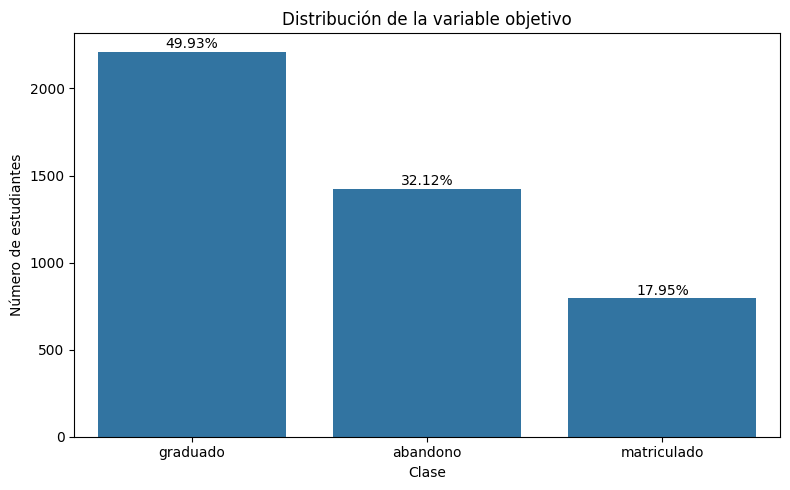

In [335]:
# Variable objetivo
TARGET = 'objetivo'

conteo_obj = df[TARGET].value_counts().sort_values(ascending=False)
porcentaje_obj = (100 * conteo_obj / conteo_obj.sum()).round(2)

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=conteo_obj.index, y=conteo_obj.values)
ax.set_title("Distribución de la variable objetivo")
ax.set_xlabel("Clase")
ax.set_ylabel("Número de estudiantes")

for i, v in enumerate(conteo_obj.values):
    ax.text(i, v + max(conteo_obj.values) * 0.01, f"{porcentaje_obj.iloc[i]}%", ha='center')

plt.tight_layout()
plt.show()


## 4. Análisis de las variables     
Como el dataset tiene muchas variables, me parece más claro organizarlas por bloques temáticos, como se explican en el enunciado. Así puedo analizar cada grupo por separado y justificar mejor las decisiones de limpieza y transformación. Los grupos de variables serán:  
1) Demográficas y personales    
2) De acceso y contexto académico previo    
3) Socioeconómias y administrativas 
4) Macroeconómicas y de entorno 
5) Rendimiento del primer semestre  
6) Rendimiento del segundo semestre     

En general, lo que haré será: codificar las variables binarias directamente a 0/1, reagrupar las variables categóricas con muchas categorías poco frecuentes para reducir el ruido y facilitar la codificación one-hot, y dejar las variables numéricas sin escalar, por ahora. 


Antes de nada, voy a graficar la correlación entre las variables numéricas para saber de antemano si podemos eliminar alguna por estar muy correlacionada con alguna otra. 

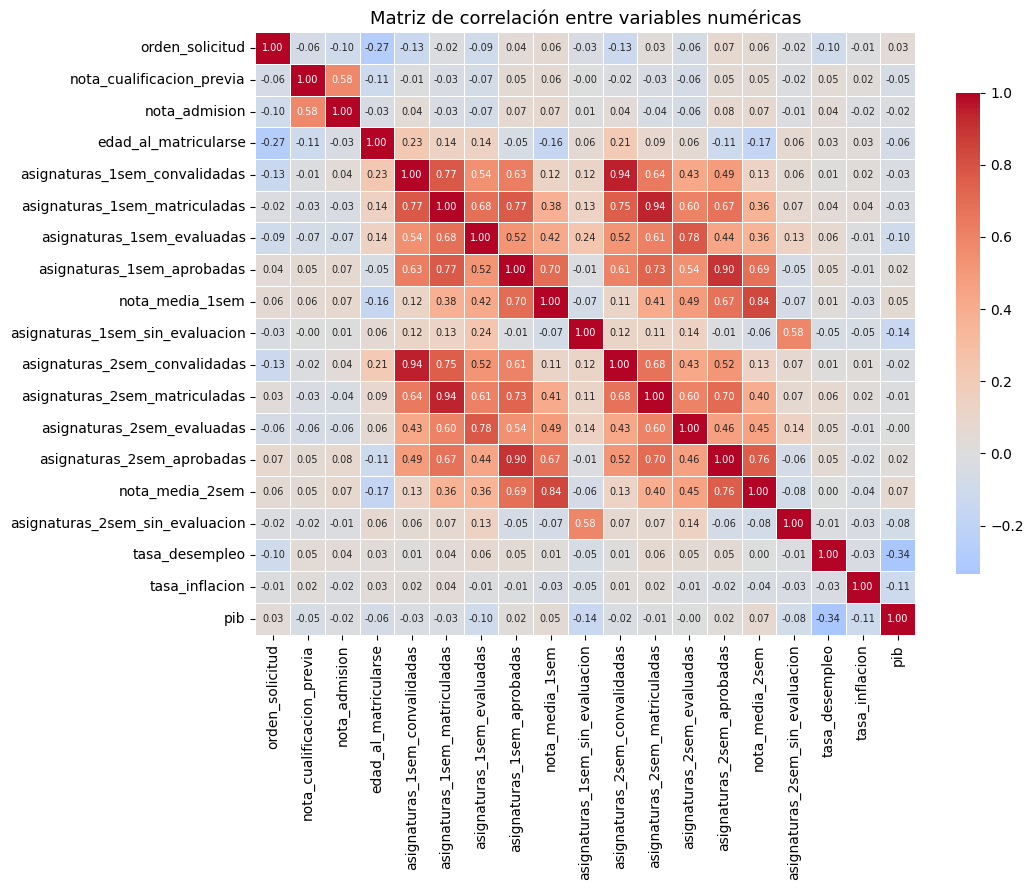

In [336]:
# correlacion entre variables numericas
numericas = [col for col in df.columns if df[col].dtype in ['int64', 'float64']]

corr_matrix = df[numericas].corr()

plt.figure(figsize=(11,9))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0,
            annot=True, fmt='.2f', annot_kws={'size': 7},
            linewidths=0.4, cbar_kws={'shrink': 0.8})
plt.title('Matriz de correlación entre variables numéricas', fontsize=13)
plt.tight_layout()
plt.show()

Observamos que ningun par de variables predictoras muestran una correlación muy alta (por ejemplo > 0.9) que pueda justificar eliminar alguna de ellas porque sean redundantes. Las correlaciones más altas se dan entre variables de rendimiento del primer semestre y del segundo, como esperabamos ver, y entre la nota de cualificación previa y la nota de admisión. Tampoco parecen muy relacionadas matrícula al día y deudor, aunque ambas variables midan el estado de pago del estudiante y podría esperarse que estuviesen correlacionadas. 

En general, no considero que en ningún caso la correlación sea suficiente como para eliminar las variables. Así que, por ahora, lo dejamos como está.

### 4.1 VARIABLES DEMOGRÁFICAS Y PERSONALES.     
Incluyen la edad de acceso, el género, la nacionalidad, el estado civil y si el estudiante está desplazado o es internacional.  

Estas variables permiten caracterizar el perfil básico del alumnado.

In [337]:
demograficas_personales = ['edad_al_matricularse', 'genero', 'nacionalidad', 'desplazado', 'internacional', 'estado_civil']
df[demograficas_personales]


,edad_al_matricularse,genero,nacionalidad,desplazado,internacional,estado_civil
0,20,hombre,portuguesa,si,no,soltero/a
1,19,hombre,portuguesa,si,no,soltero/a
2,19,hombre,portuguesa,si,no,soltero/a
3,20,mujer,portuguesa,si,no,soltero/a
4,45,mujer,portuguesa,no,no,casado/a
...,...,...,...,...,...,...
4419,19,hombre,portuguesa,no,no,soltero/a
4420,18,mujer,rusa,si,si,soltero/a
4421,30,mujer,portuguesa,si,no,soltero/a
4422,20,mujer,portuguesa,si,no,soltero/a


In [338]:
df[demograficas_personales].dtypes

edad_al_matricularse     int64
genero                  object
nacionalidad            object
desplazado              object
internacional           object
estado_civil            object
dtype: object

#### Edad al matricularse (num continua)

count    4424.000000
mean       23.265145
std         7.587816
min        17.000000
25%        19.000000
50%        20.000000
75%        25.000000
max        70.000000
Name: edad_al_matricularse, dtype: float64


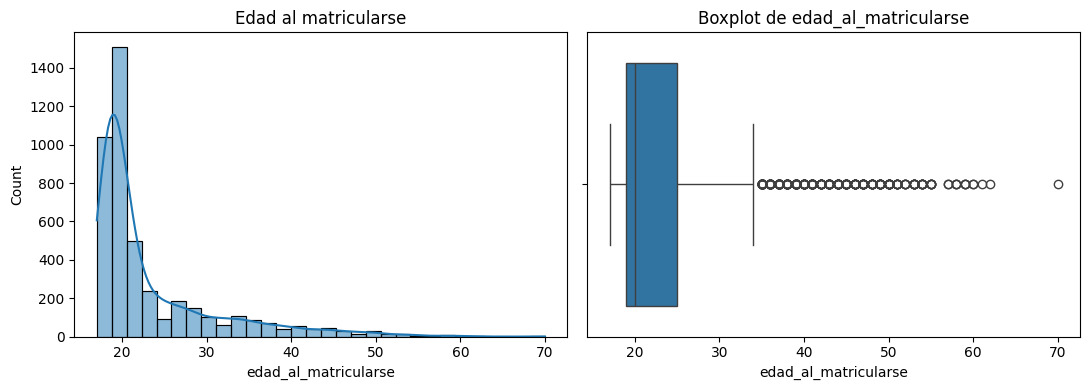

In [339]:
print(df['edad_al_matricularse'].describe())

plot_hist_box(df, 'edad_al_matricularse', titulo='Edad al matricularse')

#### Género, desplazado e internacional (binarias)      
Como las tres son variables binarias las voy a codificar directamente de si/no y mujer/hombre a 1/0. También voy a cambiar el nombre de 'genero' a 'es_mujer' para que la codificación sea más intuitiva, simplemente porque me parece más interpretable. 

In [340]:
df['genero'].value_counts()

genero
mujer     2868
hombre    1556
Name: count, dtype: int64

In [342]:
# codificación 
df["genero"] = df["genero"].replace({"hombre": 0, "mujer": 1})   
df["desplazado"] = df["desplazado"].replace({"no": 0, "si": 1})
df["internacional"] = df["internacional"].replace({"no": 0, "si": 1})

# Renombro genero
df = df.rename(columns={'genero': 'es_mujer'})
demograficas_personales.remove('genero')
demograficas_personales.append('es_mujer')

C:\Users\veror\AppData\Local\Temp\ipykernel_13104\921355407.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["genero"] = df["genero"].replace({"hombre": 0, "mujer": 1})
C:\Users\veror\AppData\Local\Temp\ipykernel_13104\921355407.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["desplazado"] = df["desplazado"].replace({"no": 0, "si": 1})
C:\Users\veror\AppData\Local\Temp\ipykernel_13104\921355407.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the o

#### Nacionalidad (categórica)      
Como la aplastante mayoria de estudiantes son portugueses y hay muy poca variabilidad. Además, no considero muy relevante la nacionalidad para determinar la trayectoria académica, y ya hay otra variable que indica si el estudiante es internacional. Por lo que he decidido eliminarla directamente.

nacionalidad
portuguesa      4314
brasilena         38
santotomense      14
espanola          13
caboverdiana      13
guineana           5
moldava            3
italiana           3
ucraniana          3
rumana             2
angolana           2
mexicana           2
mozambiquena       2
alemana            2
rusa               2
turca              1
neerlandesa        1
colombiana         1
cubana             1
inglesa            1
lituana            1
Name: count, dtype: int64


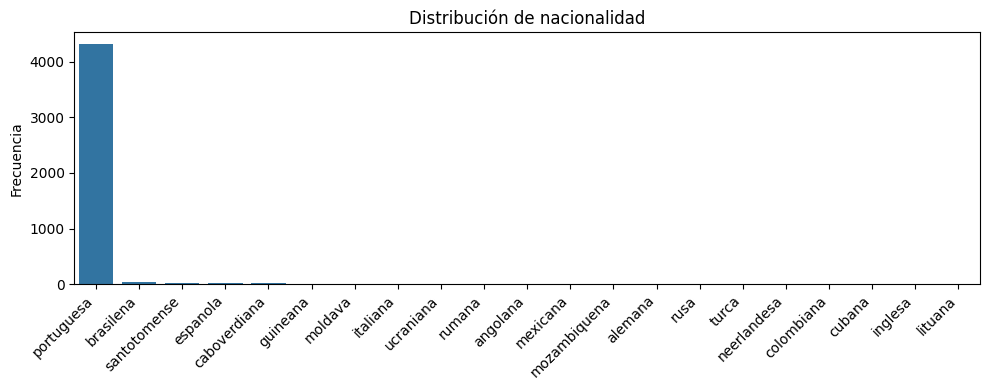

In [343]:
print(df['nacionalidad'].value_counts())

plot_bar_frecuencias(df['nacionalidad'], titulo='Distribución de nacionalidad')

# Eliminamos la columna
df = df.drop(columns='nacionalidad')

#### Estado civil (categórica)      

Recodificamos la variable a binaria con pareja = 1 y sin pareja = 0.

estado_civil
soltero/a                3919
casado/a                  379
divorciado/a               91
union_de_hecho             25
separado/a_legalmente       6
viudo/a                     4
Name: count, dtype: int64


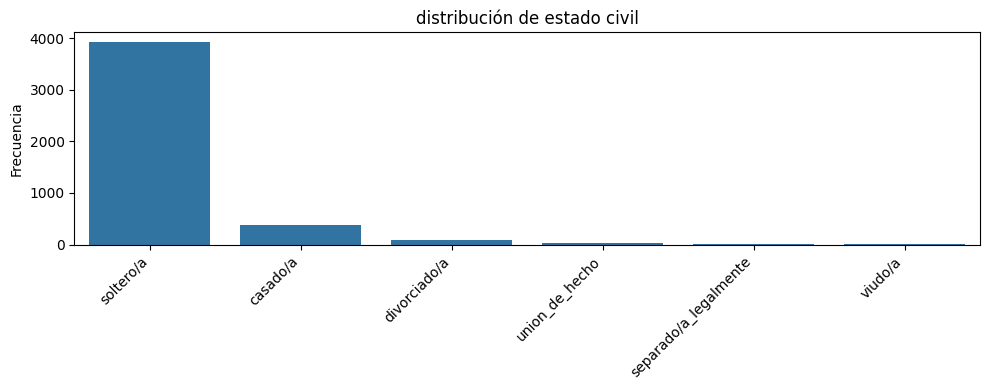

Despues de la transfrmación: 
estado_civil
0    4020
1     404
Name: count, dtype: int64


C:\Users\veror\AppData\Local\Temp\ipykernel_13104\1291828093.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['estado_civil'] = df['estado_civil'].replace({'soltero/a':0, 'casado/a':1, 'divorciado/a':0, 'union_de_hecho':1, 'separado/a_legalmente':0, 'viudo/a':0})


In [344]:
print(df['estado_civil'].value_counts())

plot_bar_frecuencias(df['estado_civil'], titulo='distribución de estado civil')

# La separo en dos grupos: con pareja (1) y sin pareja (0)
df['estado_civil'] = df['estado_civil'].replace({'soltero/a':0, 'casado/a':1, 'divorciado/a':0, 'union_de_hecho':1, 'separado/a_legalmente':0, 'viudo/a':0})

print("Despues de la transfrmación: ")
print(df['estado_civil'].value_counts())

### 4.2 VARIABLES DE ACCESO Y CONTEXTO ACADÉMICO PREVIO      
Recogen información sobre la vía de acceso a la universidad, el tipo de titulación o curso previo, la nota de acceso, la nota de la cualificación
previa, el orden de preferencia de la titulación y la ocupación o nivel formativo de los progenitores.
Este bloque resulta especialmente relevante para estudiar el rendimiento esperado antes del comienzo
de los estudios universitarios.

In [345]:
contexto_previo = ['modo_solicitud', 'orden_solicitud', 'curso', 'asistencia_diurna_vespertina', 'cualificacion_previa', 
                   'nota_cualificacion_previa','cualificacion_madre', 'cualificacion_padre','ocupacion_madre', 'ocupacion_padre',
                    'nota_admision']
df[contexto_previo]

,modo_solicitud,orden_solicitud,curso,asistencia_diurna_vespertina,cualificacion_previa,nota_cualificacion_previa,cualificacion_madre,cualificacion_padre,ocupacion_madre,ocupacion_padre,nota_admision
0,2a_fase_contingente_general,5,animacion_y_diseno_multimedia,diurna,educacion_secundaria,122.0,educacion_basica_3er_ciclo_o_equivalente,otro_11o_ano,trabajadoras_de_servicios_personales_seguridad...,trabajadores_no_cualificados,127.3
1,estudiante_internacional_licenciatura,1,turismo,diurna,educacion_secundaria,160.0,educacion_secundaria_12o_ano_o_equivalente,educacion_superior_grado,tecnicos_y_profesiones_de_nivel_intermedio,tecnicos_y_profesiones_de_nivel_intermedio,142.5
2,1a_fase_contingente_general,5,diseno_de_comunicacion,diurna,educacion_secundaria,122.0,educacion_basica_1er_ciclo_o_equivalente,educacion_basica_1er_ciclo_o_equivalente,trabajadoras_no_cualificadas,trabajadores_no_cualificados,124.8
3,2a_fase_contingente_general,2,periodismo_y_comunicacion,diurna,educacion_secundaria,122.0,educacion_basica_2o_ciclo_o_equivalente,educacion_basica_1er_ciclo_o_equivalente,trabajadoras_de_servicios_personales_seguridad...,tecnicos_y_profesiones_de_nivel_intermedio,119.6
4,mayor_de_23_anos,1,servicio_social_nocturno,vespertina,educacion_secundaria,100.0,educacion_basica_1er_ciclo_o_equivalente,educacion_basica_2o_ciclo_o_equivalente,trabajadoras_no_cualificadas,trabajadores_no_cualificados,141.5
...,...,...,...,...,...,...,...,...,...,...,...
4419,1a_fase_contingente_general,6,periodismo_y_comunicacion,diurna,educacion_secundaria,125.0,educacion_secundaria_12o_ano_o_equivalente,educacion_secundaria_12o_ano_o_equivalente,trabajadoras_de_servicios_personales_seguridad...,personal_administrativo,122.2
4420,1a_fase_contingente_general,2,periodismo_y_comunicacion,diurna,educacion_secundaria,120.0,educacion_secundaria_12o_ano_o_equivalente,educacion_secundaria_12o_ano_o_equivalente,trabajadoras_no_cualificadas,trabajadores_no_cualificados,119.0
4421,1a_fase_contingente_general,1,enfermeria,diurna,educacion_secundaria,154.0,educacion_basica_1er_ciclo_o_equivalente,educacion_basica_1er_ciclo_o_equivalente,trabajadoras_no_cualificadas,trabajadores_no_cualificados,149.5
4422,1a_fase_contingente_general,1,gestion,diurna,educacion_secundaria,180.0,educacion_basica_1er_ciclo_o_equivalente,educacion_basica_1er_ciclo_o_equivalente,trabajadoras_cualificadas_de_industria_constru...,personal_administrativo,153.8


In [346]:
df[contexto_previo].dtypes

modo_solicitud                   object
orden_solicitud                   int64
curso                            object
asistencia_diurna_vespertina     object
cualificacion_previa             object
nota_cualificacion_previa       float64
cualificacion_madre              object
cualificacion_padre              object
ocupacion_madre                  object
ocupacion_padre                  object
nota_admision                   float64
dtype: object

#### Orden de solicitud     
Indica la preferencia con la que el estudiante eligió esa titulación, por lo que valores pequeños como 1 o 2 pueden significar motivación y valores grandes elección por descarte o desmotivación.

count    4424.000000
mean        1.727848
std         1.313793
min         0.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         9.000000
Name: orden_solicitud, dtype: float64


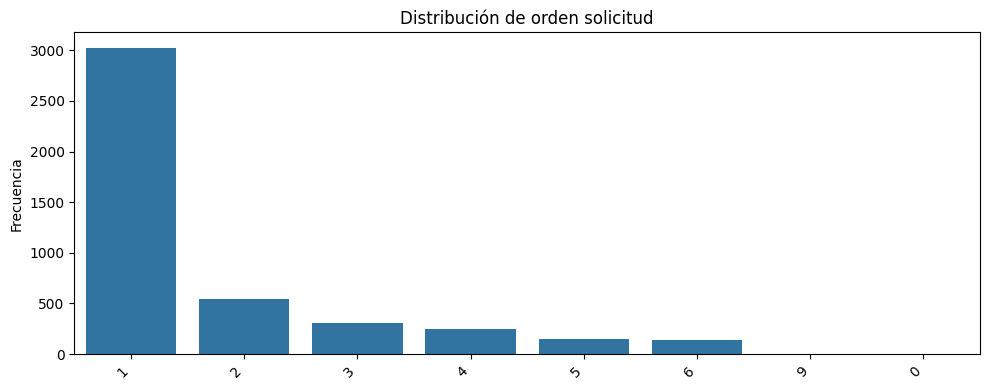

In [347]:
print(df['orden_solicitud'].describe())
plot_bar_frecuencias(df['orden_solicitud'], titulo='Distribución de orden solicitud')


#### Nota de cualificación previa y nota de admisión (numéricas)

count    4424.000000
mean      132.613314
std        13.188332
min        95.000000
25%       125.000000
50%       133.100000
75%       140.000000
max       190.000000
Name: nota_cualificacion_previa, dtype: float64


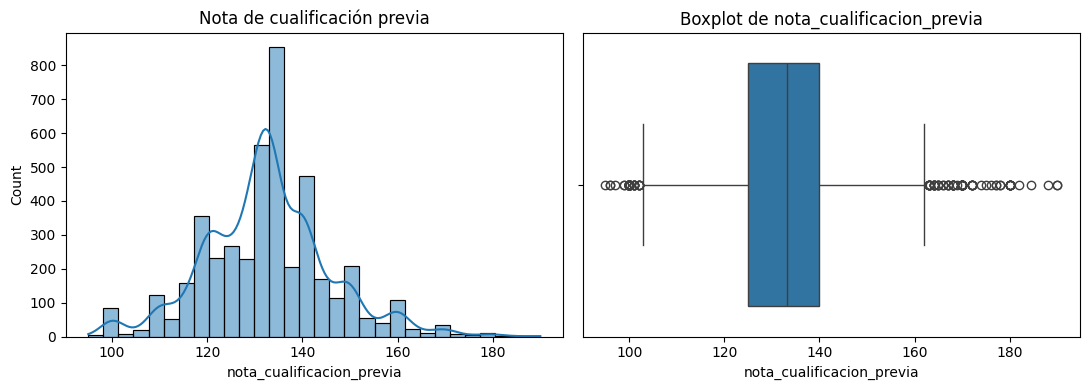

In [348]:
print(df['nota_cualificacion_previa'].describe())
plot_hist_box(df, 'nota_cualificacion_previa', titulo='Nota de cualificación previa')


count    4424.000000
mean      126.978119
std        14.482001
min        95.000000
25%       117.900000
50%       126.100000
75%       134.800000
max       190.000000
Name: nota_admision, dtype: float64


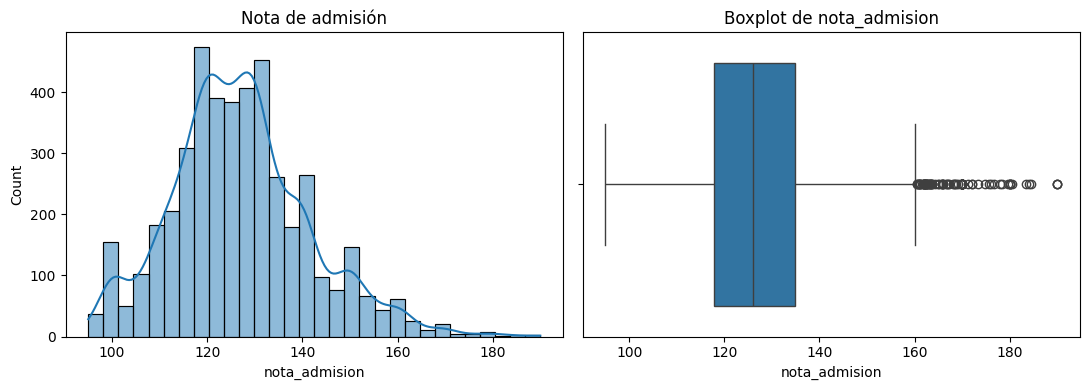

In [349]:
print(df['nota_admision'].describe())
plot_hist_box(df, 'nota_admision', titulo='Nota de admisión')


#### Modo de solicitud (categórica)      
La variable tiene muchas categorias con muy pocos estudiantes, por lo que la voy a agrupar en seis grupos: acceso general, por edad, cambios internos, con títulos previos, internacional y casos raros.

In [350]:
df['modo_solicitud'].value_counts()  #como accede el estudiante a la universidad

modo_solicitud
1a_fase_contingente_general                          1708
2a_fase_contingente_general                           872
mayor_de_23_anos                                      785
cambio_de_curso                                       312
titular_de_diploma_de_especializacion_tecnologica     213
titular_de_otro_curso_superior                        139
3a_fase_contingente_general                           124
traslado                                               77
cambio_de_institucion_curso                            59
1a_fase_contingente_especial_madeira                   38
titular_de_diploma_de_ciclo_corto                      35
estudiante_internacional_licenciatura                  30
1a_fase_contingente_especial_azores                    16
ordenanza_854_b_99                                     10
ordenanza_612_93                                        3
cambio_de_institucion_curso_internacional               1
ordenanza_533_a_99_apartado_b2_plan_diferente           1

In [351]:
def agrupar_modo(x):
    if "fase_contingente_general" in x:
        return "acceso_general"
    elif "23_anos" in x:
        return "edad"
    elif any(k in x for k in ["cambio_de_curso", "cambio_de_institucion", "traslado"]):
        return "cambios"
    elif "titular_de_" in x:
        return "titulos_previos"
    elif "internacional" in x:
        return "internacional"
    elif any(k in x for k in ["ordenanza", "contingente_especial"]):
        return "casos_raros"
    else:
        return "otros"
    
# Aplicamos agrupación sobre la propia columna
df['modo_solicitud'] = df['modo_solicitud'].apply(agrupar_modo)
print("Después de la agrupación: ")
print(df['modo_solicitud'].value_counts())

Después de la agrupación: 
modo_solicitud
acceso_general     2704
edad                785
cambios             449
titulos_previos     387
casos_raros          69
internacional        30
Name: count, dtype: int64


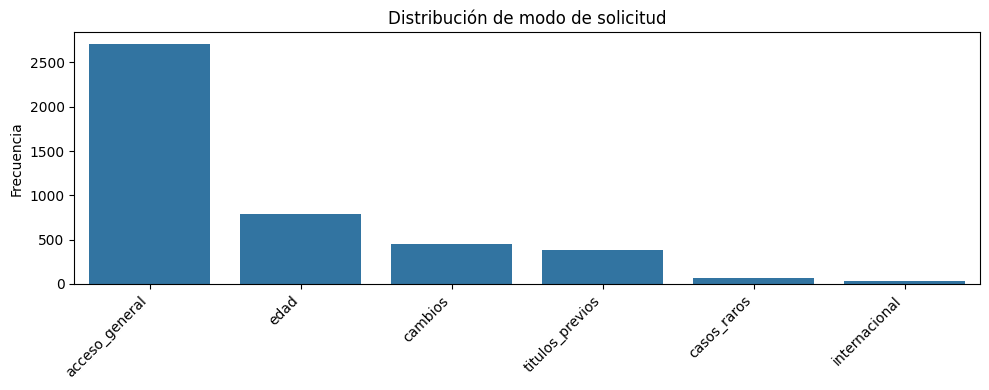

In [352]:
plot_bar_frecuencias(df['modo_solicitud'], titulo='Distribución de modo de solicitud')

#### Curso (categórica)     
Aunque las frecuencias son bastante parecidas y parece que las catgeorias están equilibaradas,voy a hacer una pequeña agrupación, porque me parece que hay carreras evidentemente similares y que se podrían añadir en el mismo grupo.

In [353]:
df['curso'].value_counts()

curso
enfermeria                                      766
gestion                                         380
servicio_social                                 355
enfermeria_veterinaria                          337
periodismo_y_comunicacion                       331
gestion_de_publicidad_y_marketing               268
gestion_nocturno                                268
turismo                                         252
diseno_de_comunicacion                          226
animacion_y_diseno_multimedia                   215
servicio_social_nocturno                        215
agronomia                                       210
educacion_basica                                192
ingenieria_informatica                          170
equicultura                                     141
higiene_oral                                     86
tecnologias_de_produccion_de_biocombustibles     12
Name: count, dtype: int64

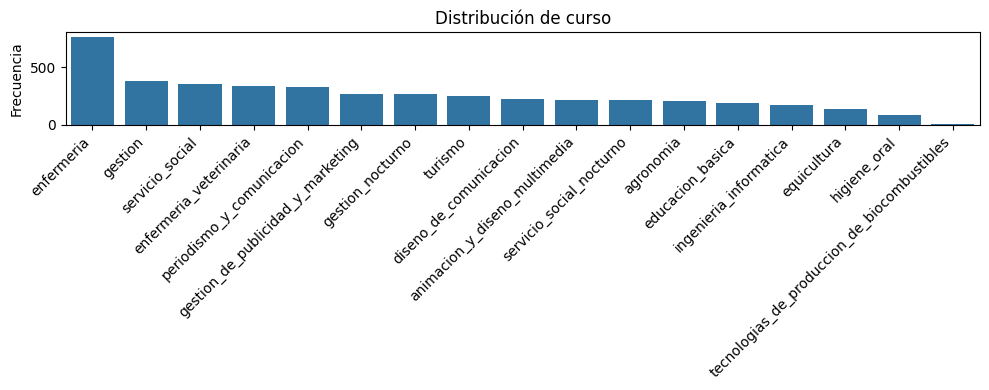

In [354]:
plot_bar_frecuencias(df['curso'], titulo='Distribución de curso')

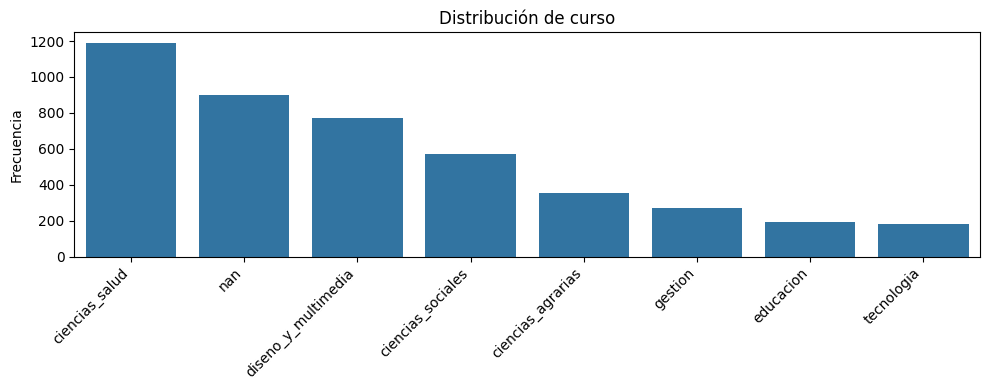

In [355]:
grupos_curso = {
    'enfermeria': 'ciencias_salud',
    'enfermeria_veterinaria': 'ciencias_salud',
    'higiene_oral': 'ciencias_salud',

    'diseno_de_comunicacion': 'diseno_y_multimedia',
    'animacion_y_diseno_multimedia': 'diseno_y_multimedia',
    'periodismo_y_comunicacion': 'diseno_y_multimedia',

    'ingenieria_informatica': 'tecnologia',
    'tecnologias_de_produccion_de_biocombustibles': 'tecnologia',

    'servicio_social': 'ciencias_sociales',
    'servicio_social_nocturno': 'ciencias_sociales',

    'educacion_basica': 'educacion',

    'gestion_nocurno': 'gestion',
    'gestion_de_publicidad_y_marketing': 'gestion',
    
    'agronomia': 'ciencias_agrarias',
    'equicultura': 'ciencias_agrarias'
}
df['curso'] = df['curso'].map(grupos_curso)
plot_bar_frecuencias(df['curso'], titulo='Distribución de curso')

#### Asistencia diurna o vespertina (binaria)       
La codificamos a diurna = 1 y vespertina = 0. Al igual que con 'genero', voy a renombrarla por comodidad, para entender el 1 como 'SI' a la asistencia diurna y el 0 como 'NO' a asistencia diurna.

In [356]:
print(df['asistencia_diurna_vespertina'].value_counts())

# Codificamos
df['asistencia_diurna_vespertina'] = df['asistencia_diurna_vespertina'].replace({'vespertina':0, 'diurna':1})

# Renombramos
df = df.rename(columns={'asistencia_diurna_vespertina': 'asistencia_diurna'})
contexto_previo.remove('asistencia_diurna_vespertina')
contexto_previo.append('asistencia_diurna') 

asistencia_diurna_vespertina
diurna        3941
vespertina     483
Name: count, dtype: int64


C:\Users\veror\AppData\Local\Temp\ipykernel_13104\1265690790.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['asistencia_diurna_vespertina'] = df['asistencia_diurna_vespertina'].replace({'vespertina':0, 'diurna':1})


#### Cualificación previa (categórica)      
Como hay varios grupos con muy poca frecuencia, reagrupamos en un número más reducido de categorias por niveles de educación.

In [357]:
print(df['cualificacion_previa'].value_counts())

cualificacion_previa
educacion_secundaria                        3717
curso_de_especializacion_tecnologica         219
educacion_basica_3er_ciclo_o_equivalente     162
educacion_superior_grado                     126
otro_11o_ano                                  45
educacion_superior_grado_1er_ciclo            40
curso_tecnico_superior_profesional            36
educacion_superior_licenciatura               23
asistencia_previa_a_educacion_superior        16
12o_ano_no_completado                         11
educacion_superior_master                      8
educacion_basica_2o_ciclo_o_equivalente        7
educacion_superior_master_2o_ciclo             6
11o_ano_no_completado                          4
10o_ano_no_completado                          2
educacion_superior_doctorado                   1
10o_ano                                        1
Name: count, dtype: int64


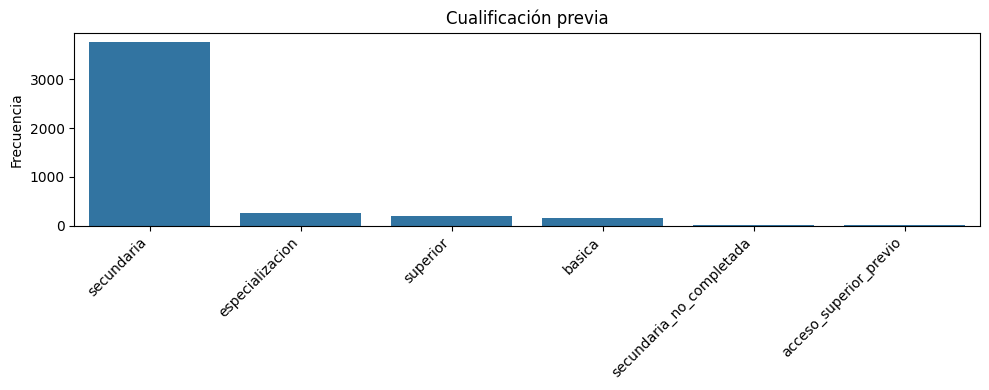

In [358]:
grupos_cual_previa = {
    'educacion_basica_3er_ciclo_o_equivalente': 'basica',
    'educacion_basica_2o_ciclo_o_equivalente': 'basica',
    'educacion_secundaria': 'secundaria',
    'otro_11o_ano': 'secundaria',
    '10o_ano': 'secundaria',
    'curso_tecnico_superior_profesional': 'especializacion',
    'curso_de_especializacion_tecnologica': 'especializacion',
    'educacion_superior_master': 'superior',
    'educacion_superior_master_2o_ciclo': 'superior',
    'educacion_superior_doctorado': 'superior',
    'educacion_superior_grado': 'superior',
    'educacion_superior_licenciatura': 'superior',
    'educacion_superior_grado_1er_ciclo': 'superior',
    '12o_ano_no_completado': 'secundaria_no_completada',
    '11o_ano_no_completado': 'secundaria_no_completada',
    '10o_ano_no_completado': 'secundaria_no_completada',
    'asistencia_previa_a_educacion_superior': 'acceso_superior_previo'
}

df['cualificacion_previa'] = df['cualificacion_previa'].map(grupos_cual_previa)
plot_bar_frecuencias(df['cualificacion_previa'], titulo='Cualificación previa')

#### Cualificación de los padres (categóricas)      
Estas variables tienen el mismo problema que la anterior, por lo que que, de la misma forma, reagrupamos en niveles de cualificación. 

In [359]:
df['cualificacion_madre'].value_counts()

cualificacion_madre
educacion_secundaria_12o_ano_o_equivalente    1069
educacion_basica_1er_ciclo_o_equivalente      1009
educacion_basica_3er_ciclo_o_equivalente       953
educacion_basica_2o_ciclo_o_equivalente        562
educacion_superior_grado                       438
desconocido                                    130
educacion_superior_licenciatura                 83
educacion_superior_master                       49
otro_11o_ano                                    42
educacion_superior_doctorado                    21
educacion_superior_grado_1er_ciclo               9
12o_ano_no_completado                            8
curso_de_especializacion_tecnologica             8
curso_superior_especializado                     6
curso_tecnico_superior_profesional               4
frecuencia_de_educacion_superior                 4
educacion_superior_master_2o_ciclo               4
8o_ano                                           3
no_sabe_leer_ni_escribir                         3
sabe_leer_s

In [360]:
grupos_cual_madre = {
    'no_sabe_leer_ni_escribir': 'sin_educacion',
    'sabe_leer_sin_4o_ano': 'sin_educacion',

    'educacion_basica_1er_ciclo_o_equivalente': 'basica',
    'educacion_basica_2o_ciclo_o_equivalente': 'basica',
    'educacion_basica_3er_ciclo_o_equivalente': 'basica',
    
    '7o_ano': 'secundaria_no_completada',
    '7o_ano_antiguo': 'secundaria_no_completada',
    '8o_ano': 'secundaria_no_completada',
    '9o_ano_no_completado': 'secundaria_no_completada',
    '10o_ano': 'secundaria_no_completada',
    '11o_ano_no_completado': 'secundaria_no_completada',
    '12o_ano_no_completado': 'secundaria_no_completada',

    '2o_ciclo_del_bachillerato_general': 'secundaria',
    'otro_11o_ano': 'secundaria',
    'educacion_secundaria_12o_ano_o_equivalente': 'secundaria',

    'curso_de_especializacion_tecnologica': 'especializacion',
    'curso_superior_especializado': 'especializacion',
    'curso_tecnico_profesional': 'especializacion',
    'curso_tecnico_superior_profesional': 'especializacion',
    'curso_general_de_comercio': 'especializacion',

    'frecuencia_de_educacion_superior': 'superior',
    'educacion_superior_grado_1er_ciclo': 'superior',
    'educacion_superior_grado': 'superior',
    'educacion_superior_licenciatura': 'superior',
    'educacion_superior_master': 'superior',
    'educacion_superior_master_2o_ciclo': 'superior',
    'educacion_superior_doctorado': 'superior',
    'educacion_superior_doctorado_3er_ciclo': 'superior',
    'desconocido': 'desconocido'
}

df['cualificacion_madre'] = df['cualificacion_madre'].map(grupos_cual_madre)

In [361]:
df['cualificacion_padre'].value_counts()

cualificacion_padre
educacion_basica_1er_ciclo_o_equivalente           1209
educacion_basica_3er_ciclo_o_equivalente            968
educacion_secundaria_12o_ano_o_equivalente          904
educacion_basica_2o_ciclo_o_equivalente             702
educacion_superior_grado                            282
desconocido                                         112
educacion_superior_licenciatura                      68
educacion_superior_master                            39
otro_11o_ano                                         38
curso_de_especializacion_tecnologica                 20
educacion_superior_doctorado                         18
7o_ano_antiguo                                       10
sabe_leer_sin_4o_ano                                  8
12o_ano_no_completado                                 5
educacion_superior_grado_1er_ciclo                    5
10o_ano                                               4
8o_ano                                                4
curso_tecnico_profesional   

In [362]:
grupos_cual_padre = {
    'no_sabe_leer_ni_escribir': 'sin_educacion',
    'sabe_leer_sin_4o_ano': 'sin_educacion',

    'educacion_basica_1er_ciclo_o_equivalente': 'basica',
    'educacion_basica_2o_ciclo_o_equivalente': 'basica',
    'educacion_basica_3er_ciclo_o_equivalente': 'basica',

    '7o_ano': 'secundaria_no_completada',
    '7o_ano_antiguo': 'secundaria_no_completada',
    '8o_ano': 'secundaria_no_completada',
    '9o_ano_no_completado': 'secundaria_no_completada',
    '10o_ano': 'secundaria_no_completada',
    '11o_ano_no_completado': 'secundaria_no_completada',
    '12o_ano_no_completado': 'secundaria_no_completada',

    '2o_ciclo_del_bachillerato_general': 'secundaria',
    'otro_11o_ano': 'secundaria',
    'educacion_secundaria_12o_ano_o_equivalente': 'secundaria',
    'curso_complementario_de_secundaria_no_concluido': 'secundaria',

    '2o_ano_complementario_de_secundaria': 'complementario_secundaria',
    'contabilidad_y_administracion_complementaria': 'complementario_secundaria',
    'curso_complementario_de_secundaria': 'complementario_secundaria',

    'curso_de_especializacion_tecnologica': 'especializacion',
    'curso_superior_especializado': 'especializacion',
    'curso_tecnico_profesional': 'especializacion',
    'curso_tecnico_superior_profesional': 'especializacion',

    'curso_general_de_comercio': 'curso_general',
    'curso_general_de_administracion_y_comercio': 'curso_general',
    
    'frecuencia_de_educacion_superior': 'superior',
    'educacion_superior_grado_1er_ciclo': 'superior',
    'educacion_superior_grado': 'superior',
    'educacion_superior_licenciatura': 'superior',
    'educacion_superior_master': 'superior',
    'educacion_superior_master_2o_ciclo': 'superior',
    'educacion_superior_doctorado': 'superior',
    'educacion_superior_doctorado_3er_ciclo': 'superior',
    'desconocido': 'desconocido'
}
df['cualificacion_padre'] = df['cualificacion_padre'].map(grupos_cual_padre)

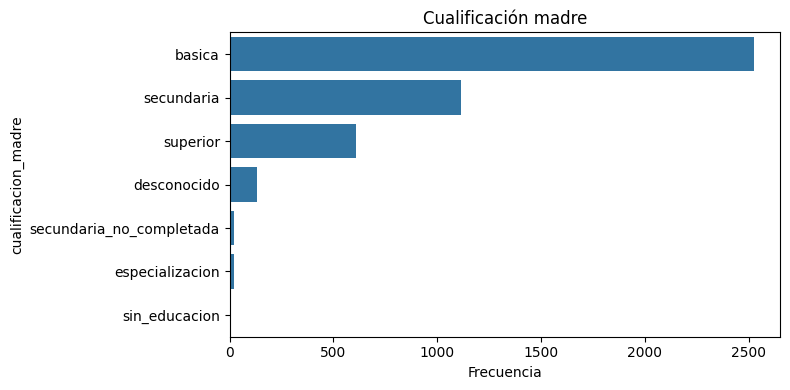

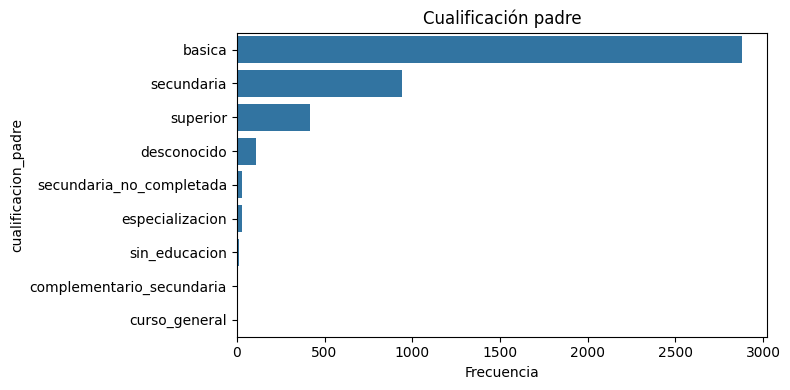

In [363]:
conteo_madre = df['cualificacion_madre'].value_counts()
fig, ax = plt.subplots(figsize=(8,4))
sns.barplot(x=conteo_madre.values, y=conteo_madre.index.astype(str), ax=ax)
ax.set_title('Cualificación madre')
ax.set_xlabel('Frecuencia')
plt.tight_layout()
plt.show()

conteo_padre = df['cualificacion_padre'].value_counts()
fig, ax = plt.subplots(figsize=(8,4))
sns.barplot(x=conteo_padre.values, y=conteo_padre.index.astype(str), ax=ax)
ax.set_title('Cualificación padre')
ax.set_xlabel('Frecuencia')
plt.tight_layout()
plt.show()

# No son muy legibles!!

#### Ocupación de los padres (categóricas)      
Para está variable, he elegido agrupar los valores por el nivel de cualificación que se necesita para cada uno. También podriamos mencionar que los de cualificación más, también están asociados a sueldos mayores y los de menor cualificación a sueldos menores, aunque no tendría que ser así exactamente pero nos sirve como orientación. Los grupos por los que la voy a separar son: alta cualificación (directivos, ingenieros), media cualificacion (administración, niveles intermedios), servicios, manual cualificado, manual no cualificado, estudiante y otros.

In [364]:
df['ocupacion_madre'].value_counts()

ocupacion_madre
trabajadoras_no_cualificadas                                                                  1577
personal_administrativo                                                                        817
trabajadoras_de_servicios_personales_seguridad_y_vendedoras                                    530
tecnicos_y_profesiones_de_nivel_intermedio                                                     351
especialistas_en_actividades_intelectuales_y_cientificas                                       318
trabajadoras_cualificadas_de_industria_construccion_y_artesania                                272
estudiante                                                                                     144
representantes_del_poder_legislativo_y_ejecutivo_directores_y_gerentes_ejecutivos              102
agricultoras_y_trabajadoras_cualificadas_de_agricultura_pesca_y_silvicultura                    91
otra_situacion                                                                               

In [365]:
grupos_ocupacion_madre = {
    'representantes_del_poder_legislativo_y_ejecutivo_directores_y_gerentes_ejecutivos': 'alta_cualificacion',
    'especialistas_en_actividades_intelectuales_y_cientificas': 'alta_cualificacion',
    'especialistas_en_tic': 'alta_cualificacion',
    'docentes': 'alta_cualificacion',
    'profesionales_de_la_salud': 'alta_cualificacion',

    'tecnicos_y_profesiones_de_nivel_intermedio': 'media_cualificacion',
    'tecnicas_y_profesionales_intermedias_de_ciencia_e_ingenieria': 'media_cualificacion',
    'tecnicas_y_profesionales_intermedias_de_salud': 'media_cualificacion',
    'tecnicas_intermedias_de_servicios_juridicos_sociales_deportivos_culturales_y_similares': 'media_cualificacion',
    'personal_administrativo': 'media_cualificacion',
    'empleadas_de_oficina_secretarias_y_operadoras_de_procesamiento_de_datos': 'media_cualificacion',

    'cuidadoras_y_trabajadoras_de_atencion_personal': 'servicios',
    'trabajadoras_de_servicios_personales': 'servicios',
    'trabajadoras_de_servicios_personales_seguridad_y_vendedoras': 'servicios',
    'vendedoras': 'servicios',
    'ayudantes_de_preparacion_de_comidas': 'servicios',

    'trabajadoras_cualificadas_de_industria_construccion_y_artesania': 'manual_cualificado',
    'trabajadoras_cualificadas_de_la_construccion_excepto_electricistas': 'manual_cualificado',
    'trabajadoras_cualificadas_de_impresion_instrumentos_de_precision_joyeria_y_artesania': 'manual_cualificado',
    'agricultoras_y_trabajadoras_cualificadas_de_agricultura_pesca_y_silvicultura': 'manual_cualificado',

    'trabajadoras_no_cualificadas': 'manual_no_cualificado',
    'trabajadoras_no_cualificadas_de_industria_extractiva_construccion_manufactura_y_transporte': 'manual_no_cualificado',
    'trabajadoras_no_cualificadas_de_agricultura_ganaderia_pesca_y_silvicultura': 'manual_no_cualificado',

    'estudiante': 'estudiante',
    'otra_situacion': 'otros',
    'en_blanco': 'otros'
}
df['ocupacion_madre'] = df['ocupacion_madre'].map(grupos_ocupacion_madre)

In [366]:
df['ocupacion_padre'].value_counts()


ocupacion_padre
trabajadores_no_cualificados                                                                              1010
trabajadores_cualificados_de_industria_construccion_y_artesania                                            666
trabajadores_de_servicios_personales_seguridad_y_vendedores                                                516
personal_administrativo                                                                                    386
tecnicos_y_profesiones_de_nivel_intermedio                                                                 384
operadores_de_instalaciones_y_maquinaria_y_montadores                                                      318
profesiones_de_las_fuerzas_armadas                                                                         266
agricultores_y_trabajadores_cualificados_de_agricultura_pesca_y_silvicultura                               242
especialistas_en_actividades_intelectuales_y_cientificas                                        

En este caso hay más ocupaciones que antes así que añadiré los grupos de agricultura y servicio militar.

In [367]:
grupos_ocupacion_padre = {
    'representantes_del_poder_legislativo_y_ejecutivo_directores_y_gerentes_ejecutivos': 'alta_cualificacion',
    'especialistas_en_actividades_intelectuales_y_cientificas': 'alta_cualificacion',
    'especialistas_en_tic':                                      'alta_cualificacion',
    'docentes':                                                  'alta_cualificacion',
    'profesionales_de_la_salud':                                 'alta_cualificacion',

    'tecnicos_y_profesiones_de_nivel_intermedio':                         'media_cualificacion',
    'tecnicos_y_profesionales_intermedios_de_ciencia_e_ingenieria':       'media_cualificacion',
    'tecnicos_intermedios_de_servicios_juridicos_sociales_deportivos_culturales_y_similares': 'media_cualificacion',
    'personal_administrativo':                                            'media_cualificacion',
    'empleados_de_oficina_secretarios_y_operadores_de_procesamiento_de_datos': 'media_cualificacion',

    'trabajadores_de_servicios_personales_seguridad_y_vendedores': 'servicios',
    'cuidadores_y_trabajadores_de_atencion_personal':              'servicios',
    'ayudantes_de_preparacion_de_comidas':                         'servicios',
    'vendedores':                                                  'servicios',

    'agricultores_y_trabajadores_cualificados_de_agricultura_pesca_y_silvicultura': 'agricultura',

    'trabajadores_cualificados_de_industria_construccion_y_artesania':              'manual_cualificado',
    'trabajadores_cualificados_de_la_construccion_excepto_electricistas':           'manual_cualificado',
    'trabajadores_cualificados_de_impresion_instrumentos_de_precision_joyeria_y_artesania': 'manual_cualificado',
    'operadores_de_instalaciones_y_maquinaria_y_montadores':                        'manual_cualificado',

    'trabajadores_no_cualificados':                                                          'manual_no_cualificado',
    'trabajadores_no_cualificados_de_industria_extractiva_construccion_manufactura_y_transporte': 'manual_no_cualificado',
    'trabajadores_no_cualificados_de_agricultura_ganaderia_pesca_y_silvicultura':             'manual_no_cualificado',

    'profesionales_de_las_fuerzas_armadas': 'militar',

    'estudiante':      'sin_informacion',
    'otra_situacion':  'sin_informacion',
    'en_blanco':       'sin_informacion',
}

df['ocupacion_padre'] = df['ocupacion_padre'].map(grupos_ocupacion_padre)


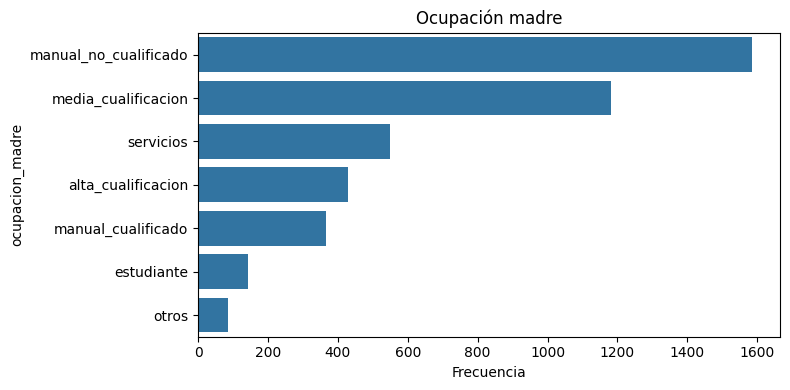

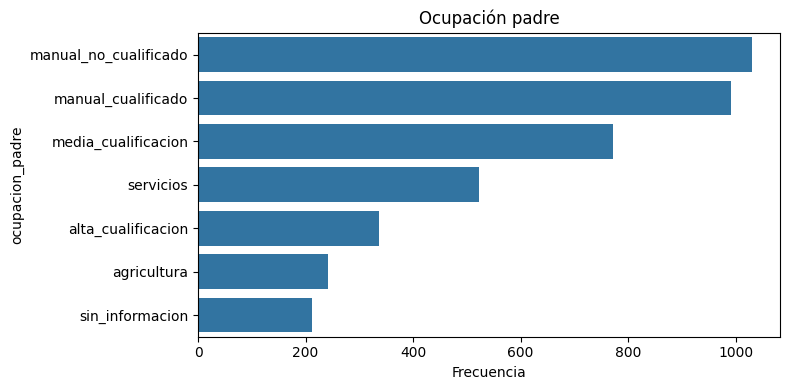

In [368]:
conteo_madre = df['ocupacion_madre'].value_counts()
fig, ax = plt.subplots(figsize=(8,4))
sns.barplot(x=conteo_madre.values, y=conteo_madre.index.astype(str), ax=ax)
ax.set_title('Ocupación madre')
ax.set_xlabel('Frecuencia')
plt.tight_layout()
plt.show()

conteo_padre = df['ocupacion_padre'].value_counts()
fig, ax = plt.subplots(figsize=(8,4))
sns.barplot(x=conteo_padre.values, y=conteo_padre.index.astype(str), ax=ax)
ax.set_title('Ocupación padre')
ax.set_xlabel('Frecuencia')
plt.tight_layout()
plt.show()


### 4.3 VARIABLES SOCIOECONÓMICAS Y ADMINISTRATIVAS      
Incluyen información sobre si el estudiante es becario, si tiene pagos al día, si es deudor, si recibe apoyo especial 
o si su situación de matrícula presenta incidencias administrativas. Estas variables pueden ser relevantes para comprender el riesgo de aban
dono y las diferencias de trayectoria académica

In [369]:
socioeconomicas = ['necesidades_educativas_especiales', 'becado', 'matricula_al_dia', 'deudor']
df[socioeconomicas]

,necesidades_educativas_especiales,becado,matricula_al_dia,deudor
0,no,no,si,no
1,no,no,no,no
2,no,no,no,no
3,no,no,si,no
4,no,no,si,no
...,...,...,...,...
4419,no,no,si,no
4420,no,no,no,si
4421,no,si,si,no
4422,no,si,si,no


Como veo que son todas categóricas binarias, las voy a codificar a 0s y 1s.

In [370]:
for col in socioeconomicas:
    df[col] = df[col].replace({'no':0, 'si':1})

C:\Users\veror\AppData\Local\Temp\ipykernel_13104\1394285701.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace({'no':0, 'si':1})


### 4.4 VARIABLES MACROECONÓMICAS Y DE ENTORNO      

El dataset incorpora también algunas variables contextuales agregadas, como tasa de desempleo, inflación o PIB. 
Aunque no describen al estudiante de forma individual, pueden utilizarse para analizar si el contexto económico general se asocia con determinadas
trayectorias académicas.

Son numéricas continuas, así que ninguna la vamos a transformar por ahora.

In [371]:
macroeconomicas = ['tasa_desempleo', 'tasa_inflacion', 'pib']
df[macroeconomicas]

,tasa_desempleo,tasa_inflacion,pib
0,10.8,1.4,1.74
1,13.9,-0.3,0.79
2,10.8,1.4,1.74
3,9.4,-0.8,-3.12
4,13.9,-0.3,0.79
...,...,...,...
4419,15.5,2.8,-4.06
4420,11.1,0.6,2.02
4421,13.9,-0.3,0.79
4422,9.4,-0.8,-3.12


       tasa_desempleo  tasa_inflacion          pib
count     4424.000000     4424.000000  4424.000000
mean        11.566139        1.228029     0.001969
std          2.663850        1.382711     2.269935
min          7.600000       -0.800000    -4.060000
25%          9.400000        0.300000    -1.700000
50%         11.100000        1.400000     0.320000
75%         13.900000        2.600000     1.790000
max         16.200000        3.700000     3.510000


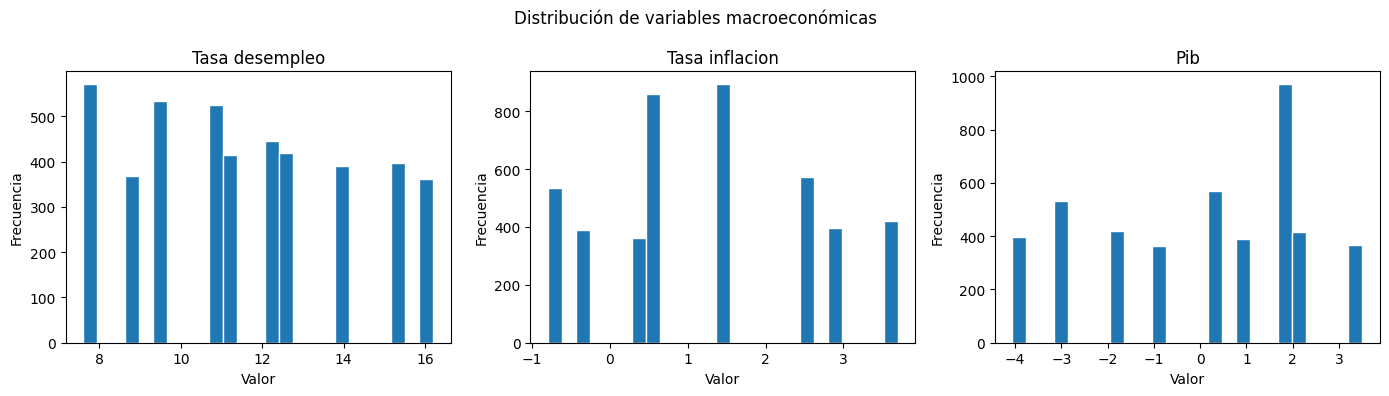

In [372]:
macroeconomicas = ['tasa_desempleo', 'tasa_inflacion', 'pib']
print(df[macroeconomicas].describe())

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, macroeconomicas):
    ax.hist(df[col], bins=25, edgecolor='white')
    ax.set_title(col.replace('_', ' ').capitalize())
    ax.set_xlabel('Valor')
    ax.set_ylabel('Frecuencia')
plt.suptitle('Distribución de variables macroeconómicas', fontsize=12)
plt.tight_layout()
plt.show()

### 4.5 VARIABLES DEL RENDIMIENTO DEL PRIMER SEMESTRE       
Se dispone de información agregada sobre el número de unidades curriculares matriculadas, evaluadas, 
aprobadas, la calificación media obtenida y el número de asignaturas sin evaluación en el primer semestre. Este bloque es muy útil para estudiar
el desempeño inicial del estudiante y su relación con el éxito posterior.

Estas variables son muy relevantes para la predicción de la trayectoria futura del estudiante. Todas son numéricas.

In [373]:
rend_semestre_1 = ['asignaturas_1sem_convalidadas', 'asignaturas_1sem_matriculadas',
                    'asignaturas_1sem_evaluadas', 'asignaturas_1sem_aprobadas',
                    'nota_media_1sem', 'asignaturas_1sem_sin_evaluacion']
df[rend_semestre_1]

,asignaturas_1sem_convalidadas,asignaturas_1sem_matriculadas,asignaturas_1sem_evaluadas,asignaturas_1sem_aprobadas,nota_media_1sem,asignaturas_1sem_sin_evaluacion
0,0,0,0,0,0.000000,0
1,0,6,6,6,14.000000,0
2,0,6,0,0,0.000000,0
3,0,6,8,6,13.428571,0
4,0,6,9,5,12.333333,0
...,...,...,...,...,...,...
4419,0,6,7,5,13.600000,0
4420,0,6,6,6,12.000000,0
4421,0,7,8,7,14.912500,0
4422,0,5,5,5,13.800000,0


In [374]:
df[rend_semestre_1].describe()

,asignaturas_1sem_convalidadas,asignaturas_1sem_matriculadas,asignaturas_1sem_evaluadas,asignaturas_1sem_aprobadas,nota_media_1sem,asignaturas_1sem_sin_evaluacion
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,0.709991,6.270570,8.299051,4.706600,10.640822,0.137658
std,2.360507,2.480178,4.179106,3.094238,4.843663,0.690880
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,5.000000,6.000000,3.000000,11.000000,0.000000
50%,0.000000,6.000000,8.000000,5.000000,12.285714,0.000000
75%,0.000000,7.000000,10.000000,6.000000,13.400000,0.000000
max,20.000000,26.000000,45.000000,26.000000,18.875000,12.000000


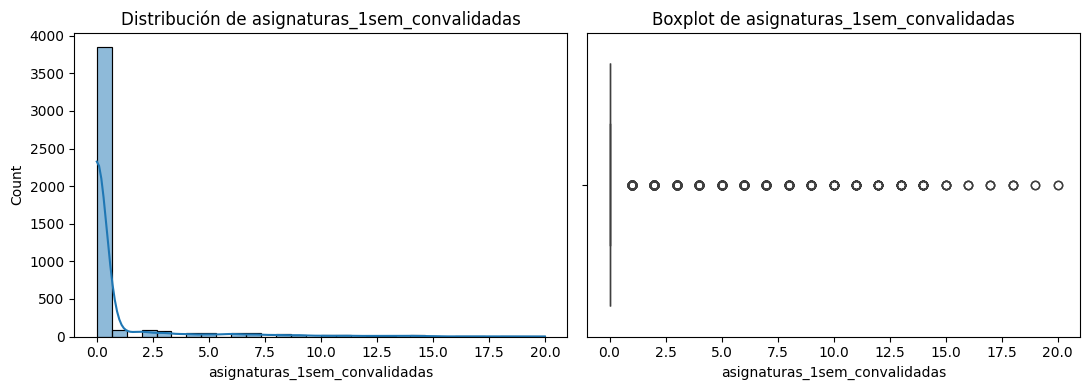

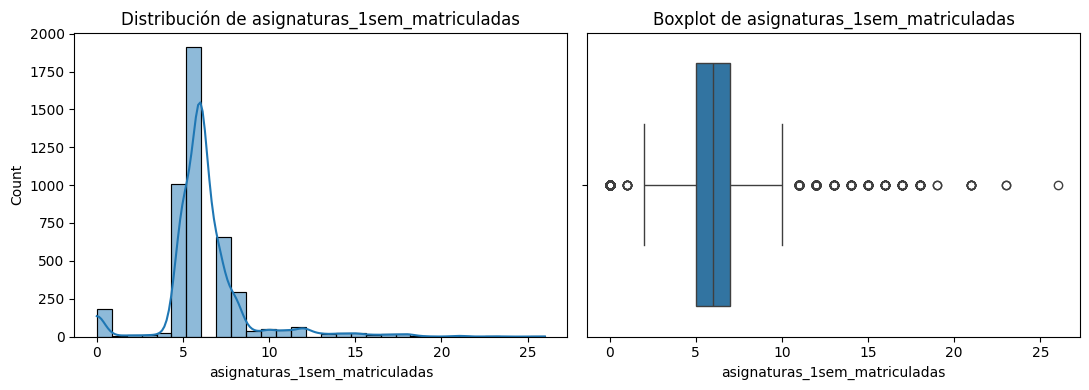

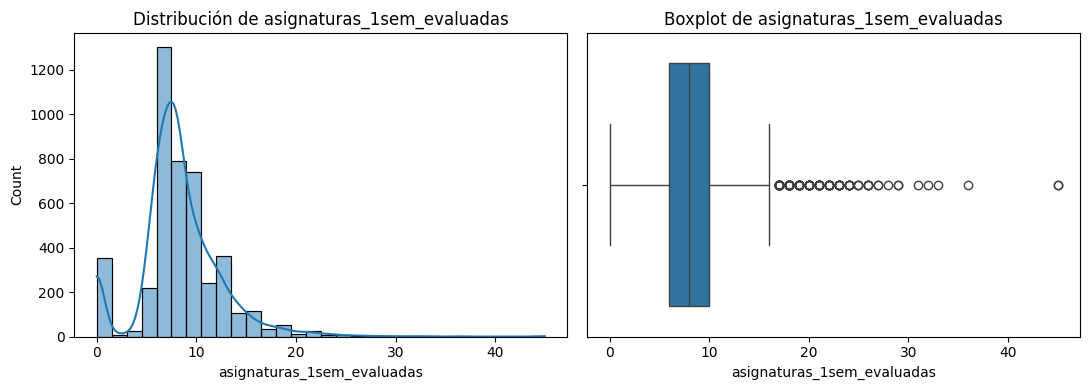

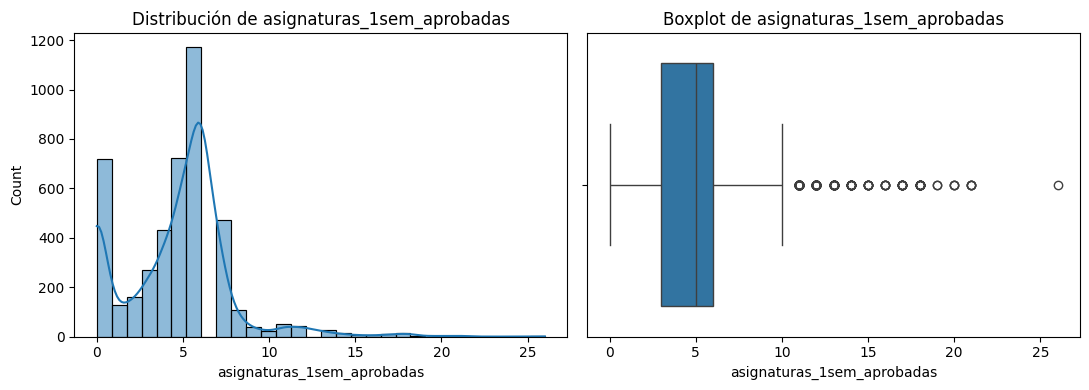

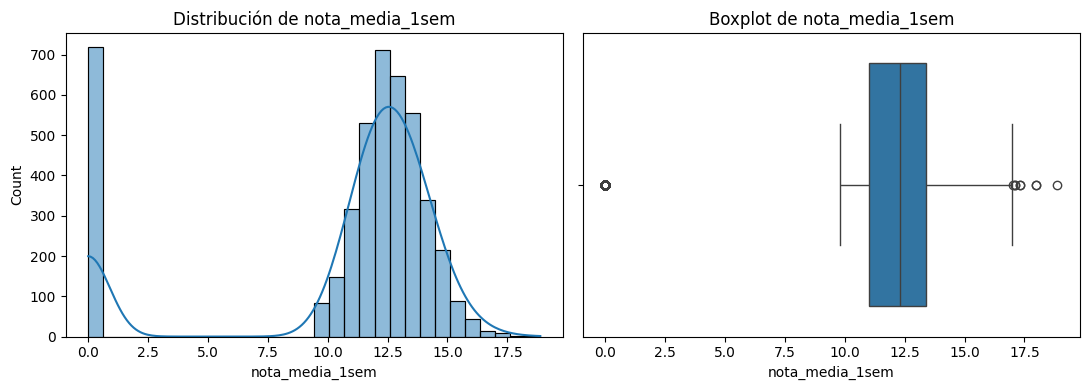

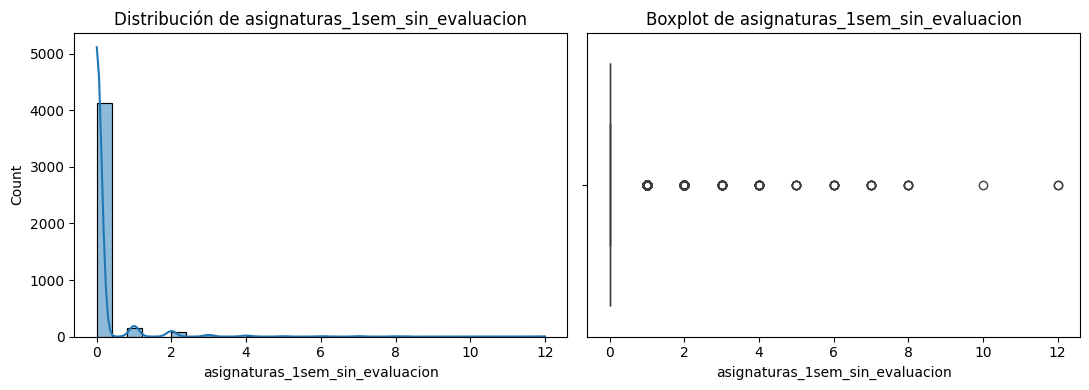

In [375]:
# Distribución de cada variable del 1er semestre
for col in rend_semestre_1:
    plot_hist_box(df, col)

### 4.6 VARIABLES DEL RENDIMIENTO DEL SEGUNDO SEMESTRE       
De forma análoga al primer semestre, se incluyen variables agregadas del segundo semestre: asignaturas matriculadas, evaluadas, aprobadas, nota
media y número de unidades sin evaluación. Estas variables son especialmente informativas, pero deben
tratarse con cuidado cuando se formulen tareas predictivas para evitar fuga de información.

In [376]:
rend_semestre_2 = ['asignaturas_2sem_convalidadas', 'asignaturas_2sem_matriculadas',
                    'asignaturas_2sem_evaluadas', 'asignaturas_2sem_aprobadas',
                    'nota_media_2sem', 'asignaturas_2sem_sin_evaluacion']
df[rend_semestre_2]

,asignaturas_2sem_convalidadas,asignaturas_2sem_matriculadas,asignaturas_2sem_evaluadas,asignaturas_2sem_aprobadas,nota_media_2sem,asignaturas_2sem_sin_evaluacion
0,0,0,0,0,0.000000,0
1,0,6,6,6,13.666667,0
2,0,6,0,0,0.000000,0
3,0,6,10,5,12.400000,0
4,0,6,6,6,13.000000,0
...,...,...,...,...,...,...
4419,0,6,8,5,12.666667,0
4420,0,6,6,2,11.000000,0
4421,0,8,9,1,13.500000,0
4422,0,5,6,5,12.000000,0


In [377]:
df[rend_semestre_2].describe()

,asignaturas_2sem_convalidadas,asignaturas_2sem_matriculadas,asignaturas_2sem_evaluadas,asignaturas_2sem_aprobadas,nota_media_2sem,asignaturas_2sem_sin_evaluacion
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316
std,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000
50%,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000
75%,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000
max,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000


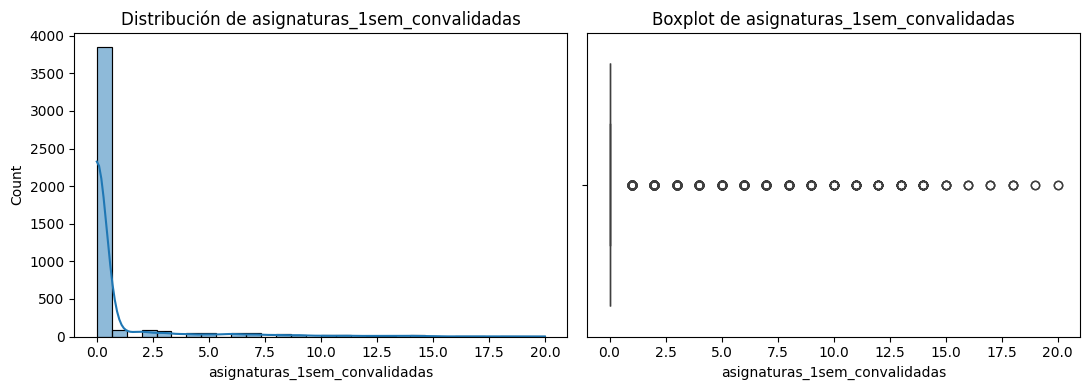

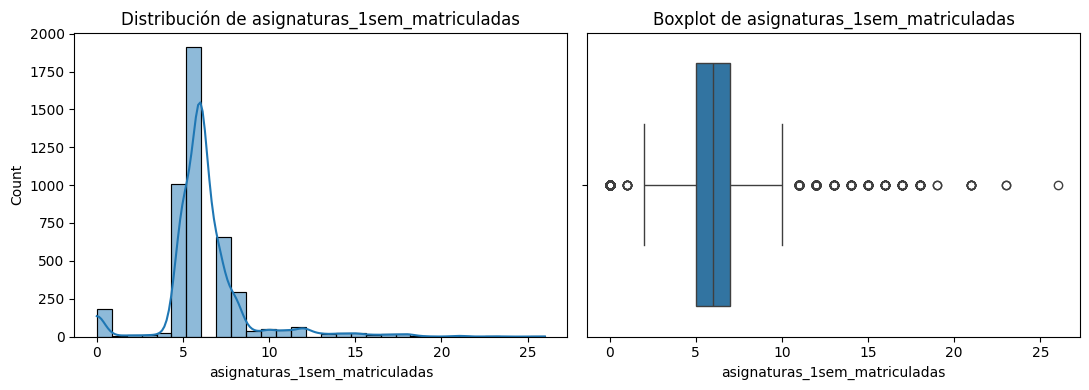

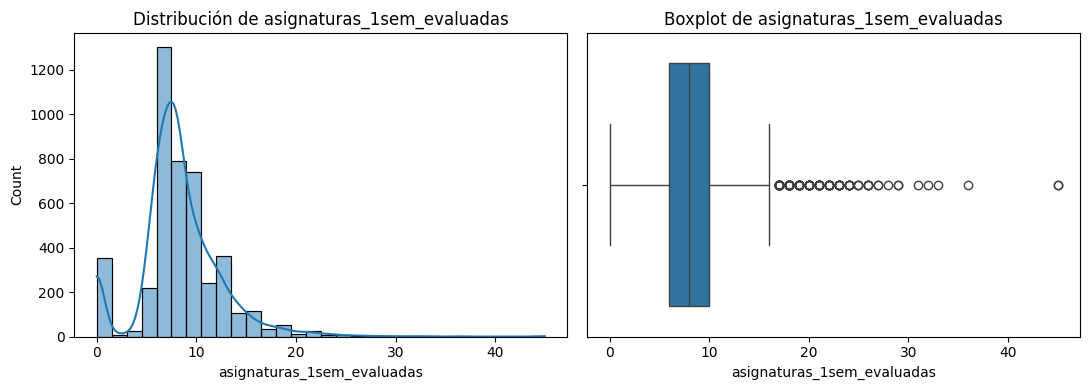

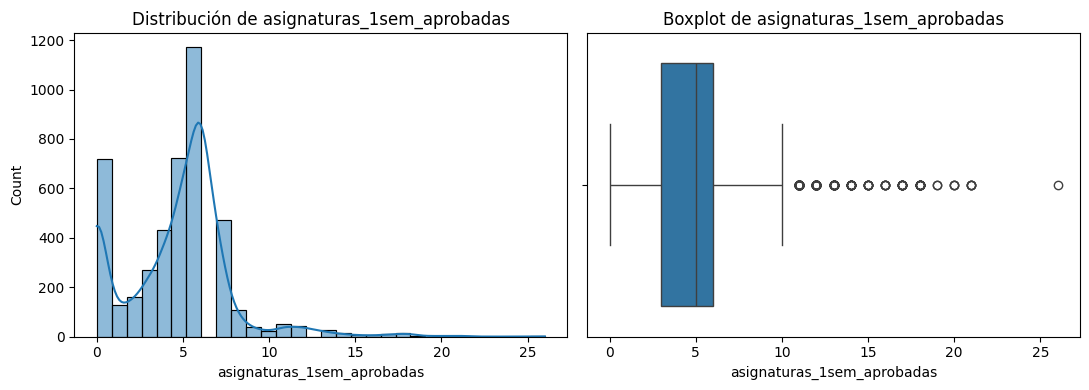

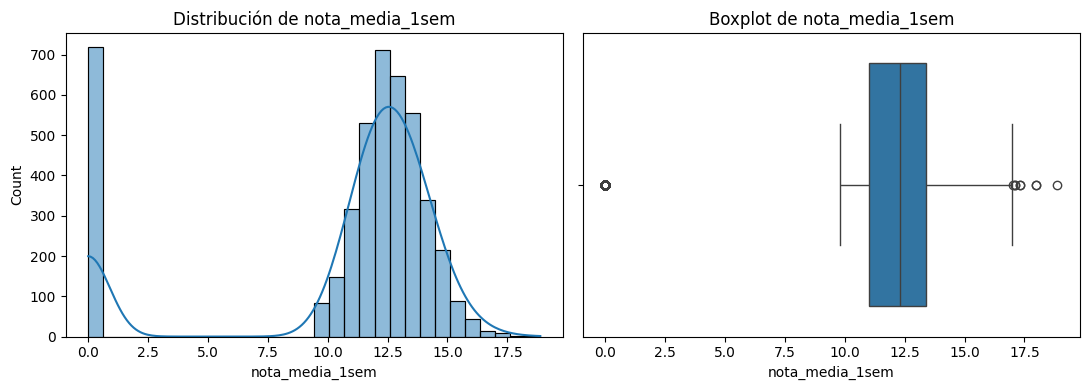

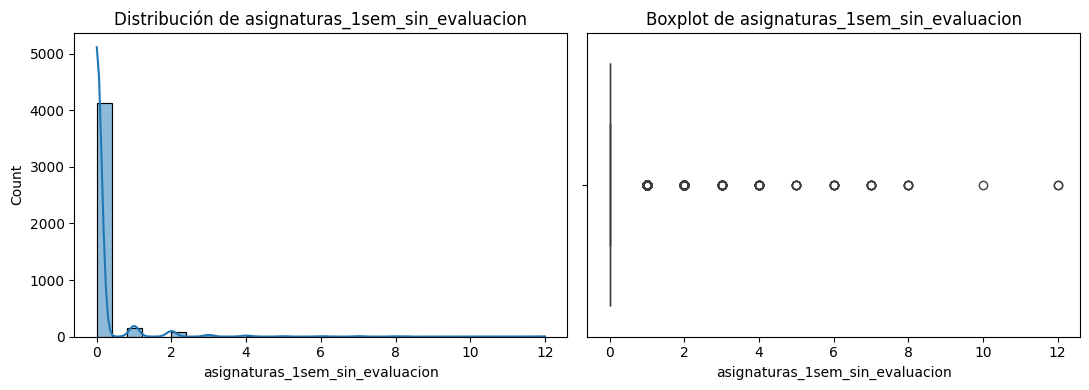

In [378]:
# Distribución de cada variable del 1er semestre
for col in rend_semestre_1:
    plot_hist_box(df, col)

### 5. Guardado del dataset preprocesado

In [379]:
df.to_pickle("../data/df_limpio.pkl")